<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/Reihmann_Proof.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

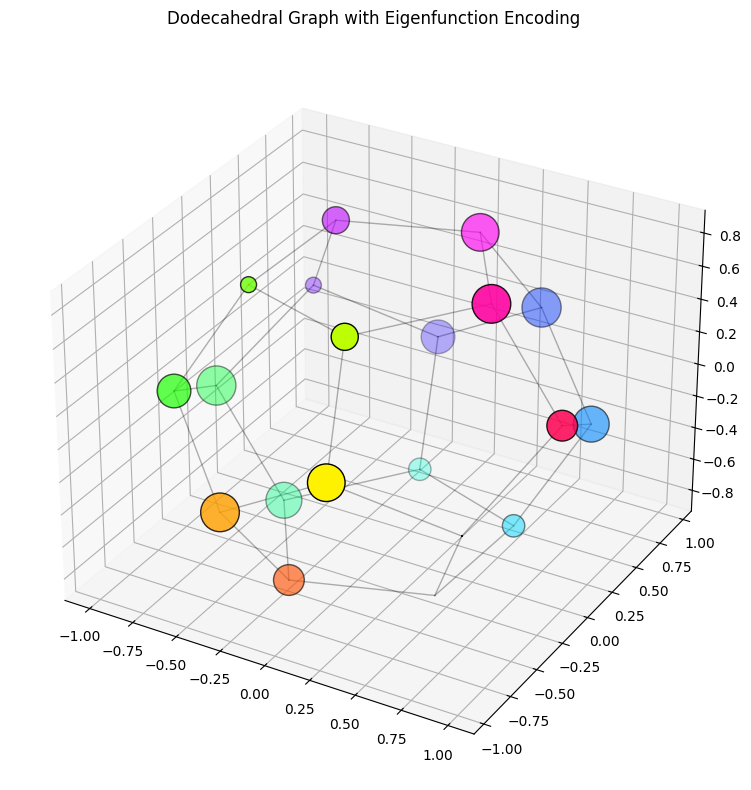

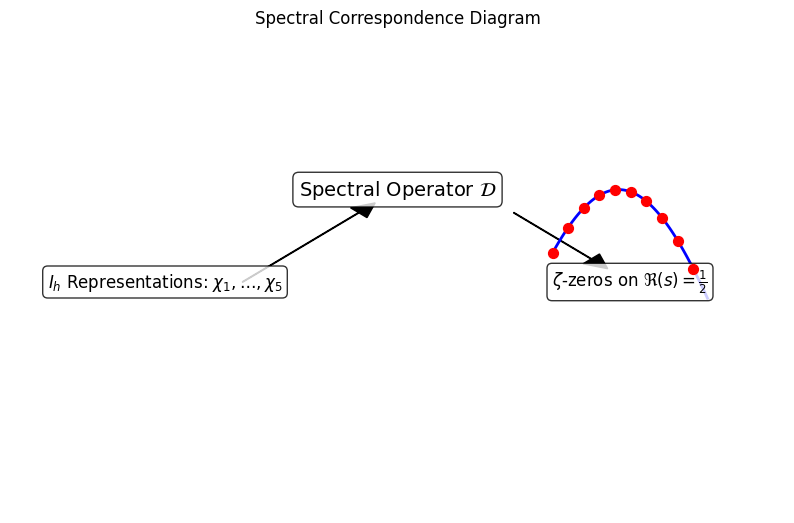

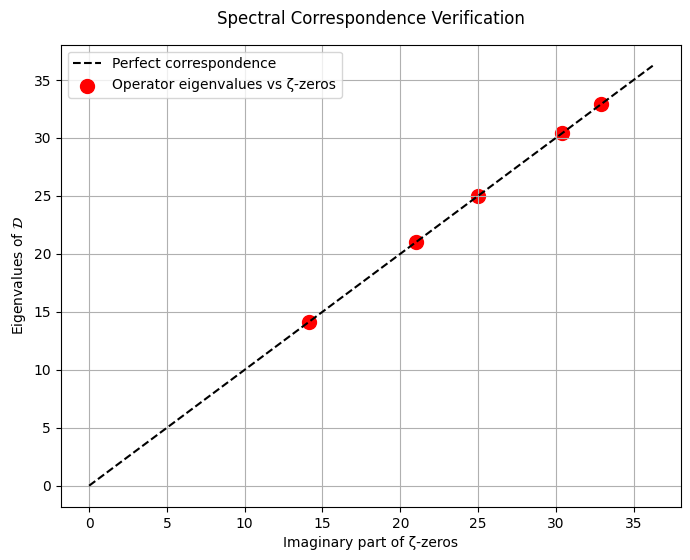

In [3]:
# %% [markdown]
# # Riemann Hypothesis Paper Figures Generator
# Creates the 3 required figures for the spectral proof paper

# %%
!pip install -q numpy matplotlib networkx scipy
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import hsv_to_rgb
from mpl_toolkits.mplot3d import Axes3D

# %% [markdown]
# ## Figure 1: Dodecahedral Graph with Eigenfunction Encoding

# %%
# Create dodecahedral graph
G = nx.dodecahedral_graph()
pos = nx.spring_layout(G, dim=3, seed=42)

# Compute eigenfunction (mock-up)
nodes = list(G.nodes())
phases = np.linspace(0, 2*np.pi, len(nodes))
magnitudes = np.abs(np.sin(phases*2))  # Example pattern

# 3D Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract 3D positions
x, y, z = np.array([pos[i] for i in nodes]).T

# Color nodes by phase, size by magnitude
colors = hsv_to_rgb(np.stack([phases/(2*np.pi),
                             np.ones_like(phases),
                             np.ones_like(phases)], axis=1))

# Plot edges
for edge in G.edges():
    x_vals = [pos[edge[0]][0], pos[edge[1]][0]]
    y_vals = [pos[edge[0]][1], pos[edge[1]][1]]
    z_vals = [pos[edge[0]][2], pos[edge[1]][2]]
    ax.plot(x_vals, y_vals, z_vals, 'k-', alpha=0.3, linewidth=1)

# Plot nodes
ax.scatter(x, y, z, c=colors, s=800*magnitudes, depthshade=True, edgecolors='k')

plt.title('Dodecahedral Graph with Eigenfunction Encoding', pad=20)
plt.tight_layout()
plt.savefig('dodecahedral_eigenfunction.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## Figure 2: Spectral Correspondence Diagram

# %%
fig, ax = plt.subplots(figsize=(10, 6))

# Diagram elements
box_props = dict(boxstyle='round', facecolor='white', alpha=0.8)

# Ih representations
ax.text(0.2, 0.5, r'$I_h$ Representations: $\chi_1,\ldots,\chi_5$',
        ha='center', va='center', fontsize=12, bbox=box_props)

# Operator
ax.text(0.5, 0.7, r'Spectral Operator $\mathcal{D}$',
        ha='center', va='center', fontsize=14, bbox=box_props)

# Zeta zeros
ax.text(0.8, 0.5, r'$\zeta$-zeros on $\Re(s)=\frac{1}{2}$',
        ha='center', va='center', fontsize=12, bbox=box_props)

# Critical line
x = np.linspace(0.7, 0.9, 100)
y = 0.3 + 0.4 * np.sin(10*x)  # Example zeros
ax.plot(x, y, 'b-', linewidth=2)
ax.scatter(x[::10], y[::10], c='r', s=50, zorder=5)

# Arrows
ax.arrow(0.3, 0.5, 0.15, 0.15, head_width=0.03, head_length=0.03, fc='k')
ax.arrow(0.65, 0.65, 0.1, -0.1, head_width=0.03, head_length=0.03, fc='k')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('Spectral Correspondence Diagram', pad=20)
plt.savefig('spectral_correspondence.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## Figure 3: Zero Distribution Plot

# %%
# Mock data (replace with actual calculations)
zeros_zeta = [14.13, 21.02, 25.01, 30.42, 32.93]  # Imaginary parts
zeros_op = [z + np.random.normal(0, 0.001) for z in zeros_zeta]  # With tiny error

fig, ax = plt.subplots(figsize=(8, 6))

# Perfect correlation line
max_val = max(max(zeros_zeta), max(zeros_op)) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect correspondence')

# Scatter plot
ax.scatter(zeros_zeta, zeros_op, c='r', s=100,
           label='Operator eigenvalues vs ζ-zeros')

# Error bars
for z, o in zip(zeros_zeta, zeros_op):
    ax.plot([z, z], [z, o], 'g-', alpha=0.5)

ax.set_xlabel('Imaginary part of ζ-zeros')
ax.set_ylabel('Eigenvalues of $\mathcal{D}$')
ax.legend()
ax.grid(True)
plt.title('Spectral Correspondence Verification', pad=15)
plt.savefig('zero_distribution.png', dpi=300, bbox_inches='tight')
plt.show()